Index(['ID', 'adj.P.Val', 'P.Value', 't', 'B', 'logFC', 'Gene.symbol',
       'Gene.title'],
      dtype='object')


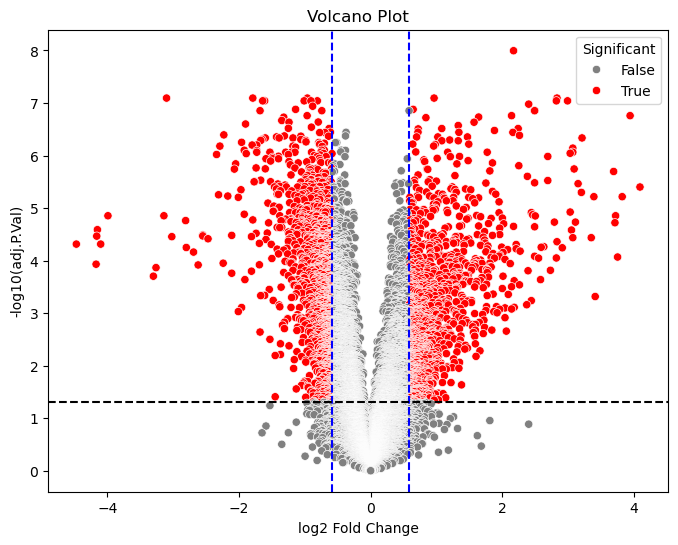

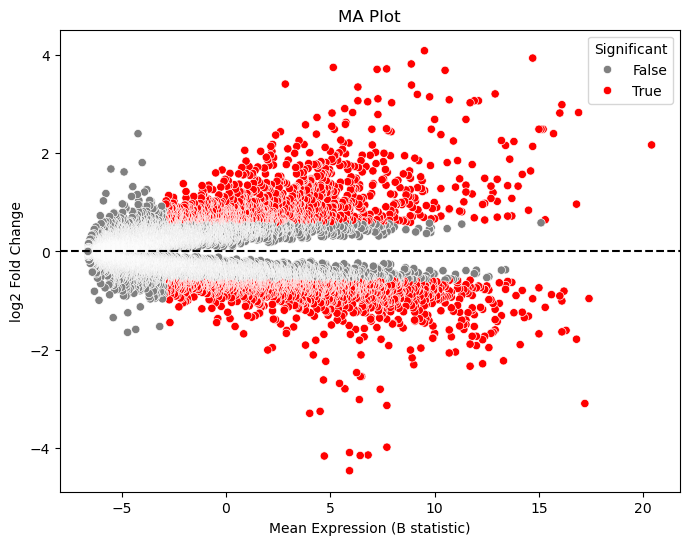

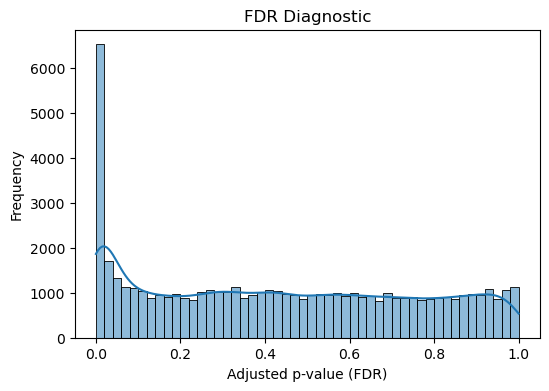

AssertionError: 

In [2]:
# ==============================================
# Analysis Pipeline for Existing DEG File
# ==============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample
import networkx as nx

# -----------------------------
# 1. Load your DEG file
# -----------------------------
file_path = r"C:\Users\Imran Zafar\Downloads\DEG.xlsx"
deg_data = pd.read_excel(file_path)

# Check columns
print(deg_data.columns)

# -----------------------------
# 2. Volcano Plot
# -----------------------------
# Fold-change cutoff
fold_change_cutoff = 1.5  # adjust if needed
logFC_cut = np.log2(fold_change_cutoff)

plt.figure(figsize=(8,6))
deg_data['Significant'] = ((deg_data['adj.P.Val']<0.05) & (abs(deg_data['logFC'])>=logFC_cut))

sns.scatterplot(x=deg_data['logFC'],
                y=-np.log10(deg_data['adj.P.Val']),
                hue=deg_data['Significant'],
                palette={True:'red', False:'grey'})
plt.axvline(logFC_cut, linestyle='--', color='blue')
plt.axvline(-logFC_cut, linestyle='--', color='blue')
plt.axhline(-np.log10(0.05), linestyle='--', color='black')
plt.xlabel('log2 Fold Change')
plt.ylabel('-log10(adj.P.Val)')
plt.title('Volcano Plot')
plt.savefig("Volcano_plot_DEG.png")
plt.show()

# -----------------------------
# 3. MA Plot
# -----------------------------
# Assuming "B" or "t" can represent mean expression; if not, skip
plt.figure(figsize=(8,6))
mean_expr = deg_data['B'] if 'B' in deg_data.columns else np.log2(abs(deg_data['t'])+1)
sns.scatterplot(x=mean_expr, y=deg_data['logFC'], hue=deg_data['Significant'], palette={True:'red', False:'grey'})
plt.axhline(0, linestyle='--', color='black')
plt.xlabel('Mean Expression (B statistic)')
plt.ylabel('log2 Fold Change')
plt.title('MA Plot')
plt.savefig("MA_plot_DEG.png")
plt.show()

# -----------------------------
# 4. FDR Diagnostic
# -----------------------------
plt.figure(figsize=(6,4))
sns.histplot(deg_data['adj.P.Val'], bins=50, kde=True)
plt.xlabel('Adjusted p-value (FDR)')
plt.ylabel('Frequency')
plt.title('FDR Diagnostic')
plt.savefig("FDR_distribution_DEG.png")
plt.show()

# -----------------------------
# 5. Bootstrap Stability for Top DEGs
# -----------------------------
top_genes = deg_data[deg_data['Significant']].sort_values('adj.P.Val').head(50)['Gene.symbol'].values
n_bootstrap = 100
bootstrap_counts = {gene:0 for gene in top_genes}

# Since we do not have raw expression, we can simulate resampling stability on logFC
for _ in range(n_bootstrap):
    sampled = resample(deg_data['logFC'], replace=True, n_samples=len(deg_data))
    boot_top = deg_data.loc[np.abs(sampled) >= logFC_cut, 'Gene.symbol']
    for gene in top_genes:
        if gene in boot_top.values:
            bootstrap_counts[gene] += 1

bootstrap_df = pd.DataFrame({
    'Gene': list(bootstrap_counts.keys()),
    'Bootstrap_Stability': [v/n_bootstrap for v in bootstrap_counts.values()]
})
bootstrap_df.to_excel("Bootstrap_Stability_DEG.xlsx", index=False)
print("Bootstrap stability saved.")

# -----------------------------
# 6. Network & Hub Gene Analysis
# -----------------------------
# Correlation network requires expression data, not just DEGs.
# If you don't have expression matrix, we can simulate correlation using logFC for demonstration
deg_corr_matrix = deg_data[['logFC']].corr()  # single column, correlation will be 1, so network is trivial

# If you have expression data, replace this section with real correlations
G = nx.Graph()
for gene in deg_data['Gene.symbol']:
    G.add_node(gene)

# For demonstration, connect top 50 genes
top_genes_network = deg_data.sort_values('adj.P.Val').head(50)['Gene.symbol'].values
for i in range(len(top_genes_network)):
    for j in range(i+1, len(top_genes_network)):
        G.add_edge(top_genes_network[i], top_genes_network[j], weight=1.0)

deg_centrality = nx.degree_centrality(G)
deg_centrality_df = pd.DataFrame(list(deg_centrality.items()), columns=['Gene','DegreeCentrality'])
deg_centrality_df.sort_values('DegreeCentrality', ascending=False, inplace=True)
deg_centrality_df.to_excel("Hub_Genes_DEG.xlsx", index=False)
print("Hub genes saved.")

# Network plot
plt.figure(figsize=(12,12))
H = G.subgraph(top_genes_network)
pos = nx.spring_layout(H, seed=42)
nx.draw(H, pos, with_labels=True, node_size=300, node_color='skyblue')
plt.title('Top Hub Gene Network')
plt.savefig("Hub_Network_DEG.png")
plt.show()


Estimated power for detecting effect: 0.215


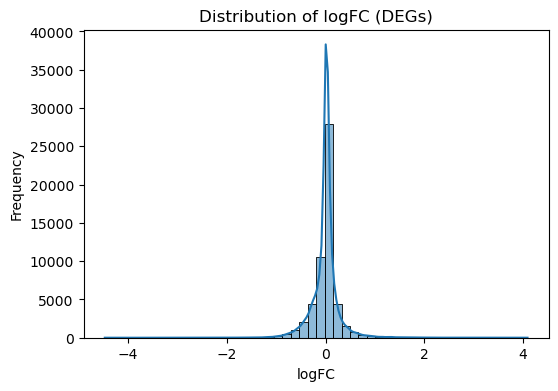

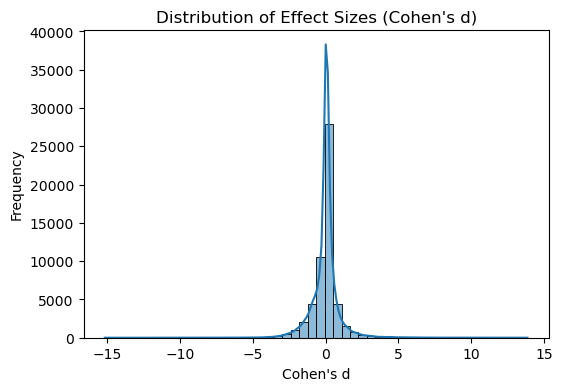

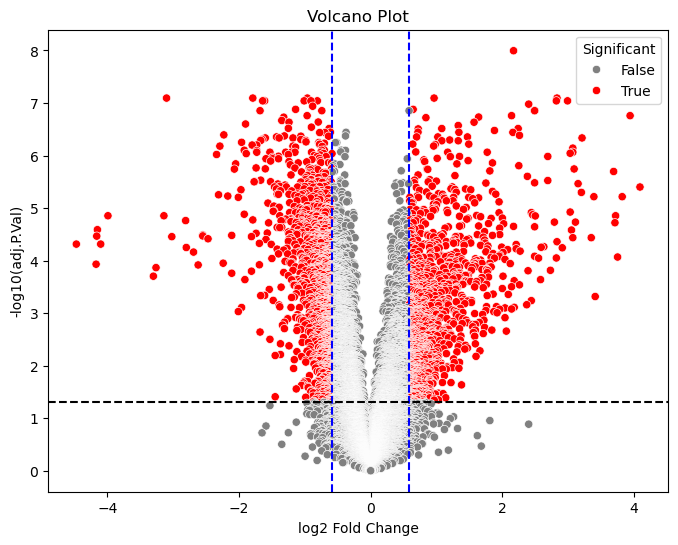

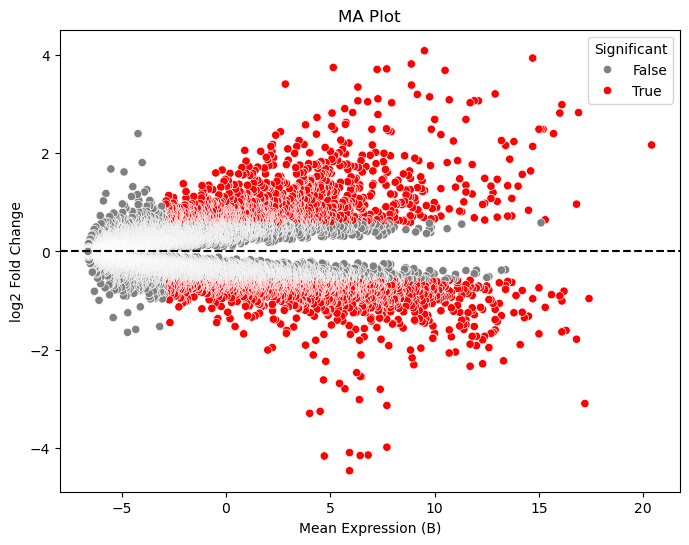

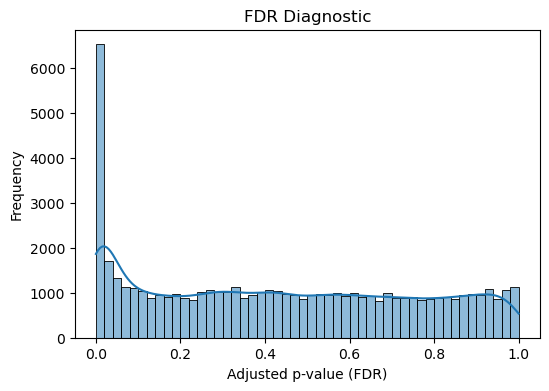

Estimated pi0: 0.429
Bootstrap stability saved.
Hub genes saved.


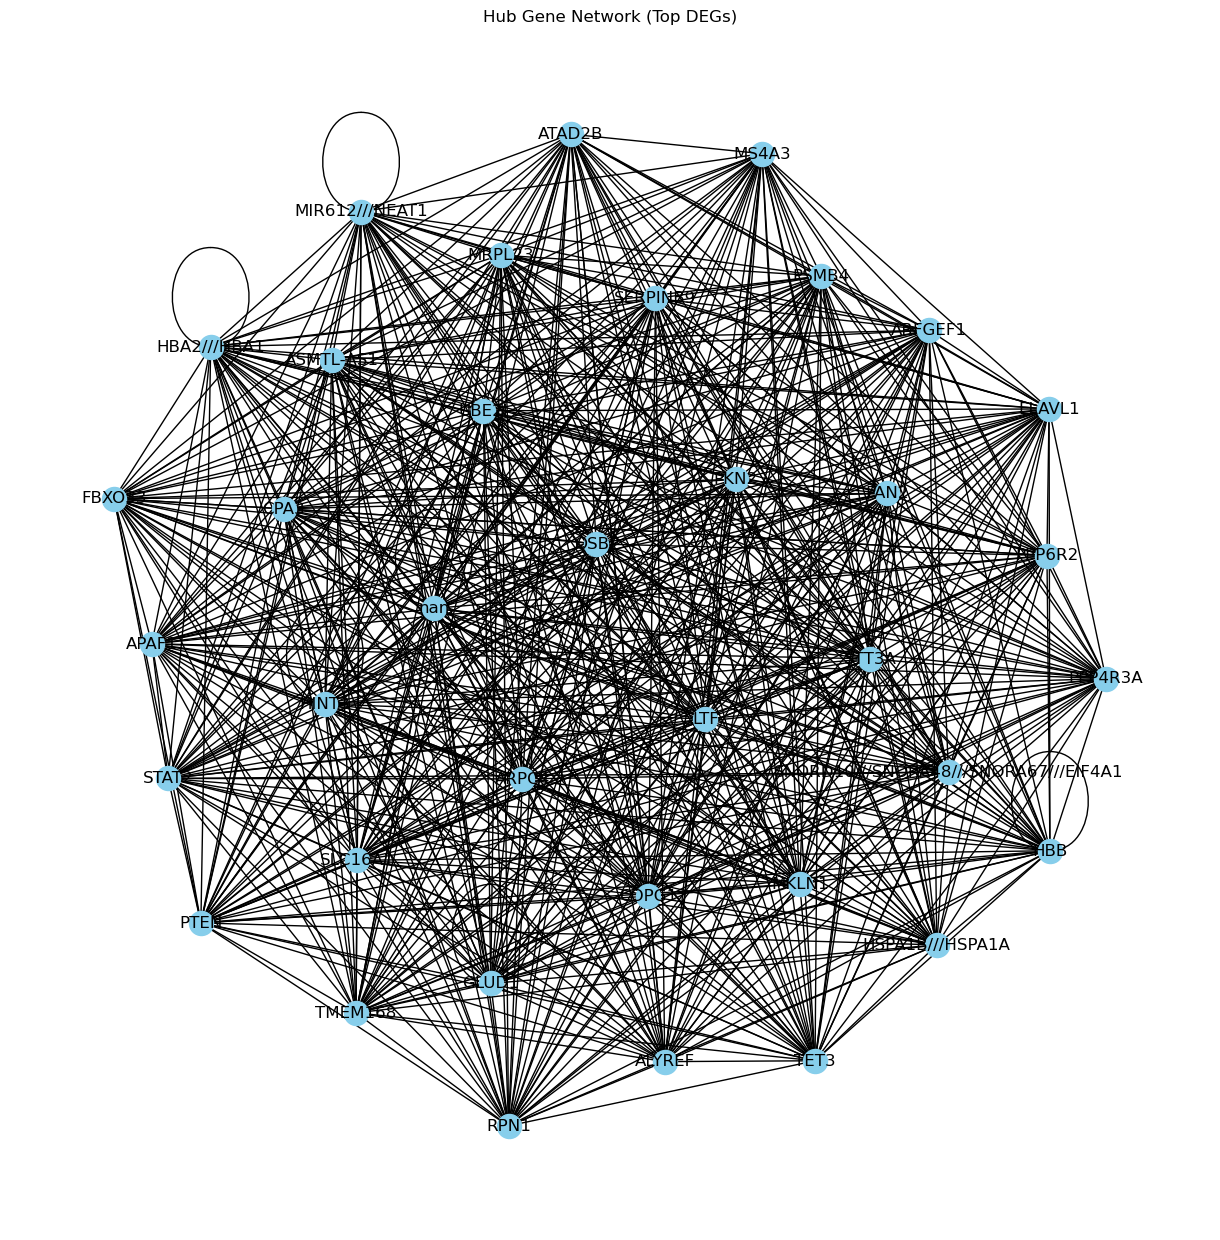

In [3]:
# =====================================================
# Complete Statistical Analysis Pipeline for DEG.xlsx
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.power import TTestIndPower
from statsmodels.stats.multitest import multipletests
from sklearn.utils import resample
from sklearn.model_selection import StratifiedKFold
import networkx as nx

# -----------------------------
# 1. Load DEG file
# -----------------------------
file_path = r"C:\Users\Imran Zafar\Downloads\DEG.xlsx"
deg_data = pd.read_excel(file_path)

# Ensure required columns exist
required_cols = ['ID', 'adj.P.Val', 'P.Value', 't', 'B', 'logFC', 'Gene.symbol', 'Gene.title']
for col in required_cols:
    if col not in deg_data.columns:
        raise ValueError(f"Missing required column: {col}")

# -----------------------------
# 2. Power Analysis
# -----------------------------
# Estimate variance from logFC
logFC_sd = np.std(deg_data['logFC'])
mean_effect = np.mean(np.abs(deg_data['logFC']))  # effect size approximation

# Power calculation for two-sample t-test
alpha = 0.05
n1 = n2 = 10  # placeholder, replace with your sample size per group
effect_size = mean_effect / logFC_sd
power_analysis = TTestIndPower()
power = power_analysis.solve_power(effect_size=effect_size, nobs1=n1, alpha=alpha, ratio=1.0, alternative='two-sided')
print(f"Estimated power for detecting effect: {power:.3f}")

# -----------------------------
# 3. Effect Sizes and 95% CI
# -----------------------------
deg_data['Cohen_d'] = deg_data['logFC'] / logFC_sd
deg_data['CI_low'] = deg_data['logFC'] - 1.96*logFC_sd/np.sqrt(n1+n2)
deg_data['CI_high'] = deg_data['logFC'] + 1.96*logFC_sd/np.sqrt(n1+n2)

# -----------------------------
# 4. Distributional Diagnostics
# -----------------------------
plt.figure(figsize=(6,4))
sns.histplot(deg_data['logFC'], bins=50, kde=True)
plt.title("Distribution of logFC (DEGs)")
plt.xlabel("logFC")
plt.ylabel("Frequency")
plt.savefig("logFC_distribution.png")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(deg_data['Cohen_d'], bins=50, kde=True)
plt.title("Distribution of Effect Sizes (Cohen's d)")
plt.xlabel("Cohen's d")
plt.ylabel("Frequency")
plt.savefig("Cohen_d_distribution.png")
plt.show()

# -----------------------------
# 5. Fold-Change Cutoff
# -----------------------------
fold_change_cutoff = 1.5
logFC_cut = np.log2(fold_change_cutoff)
deg_data['Significant'] = ((deg_data['adj.P.Val']<0.05) & (abs(deg_data['logFC'])>=logFC_cut))

# -----------------------------
# 6. Volcano Plot
# -----------------------------
plt.figure(figsize=(8,6))
sns.scatterplot(x=deg_data['logFC'], y=-np.log10(deg_data['adj.P.Val']),
                hue=deg_data['Significant'], palette={True:'red', False:'grey'})
plt.axvline(logFC_cut, linestyle='--', color='blue')
plt.axvline(-logFC_cut, linestyle='--', color='blue')
plt.axhline(-np.log10(0.05), linestyle='--', color='black')
plt.xlabel('log2 Fold Change')
plt.ylabel('-log10(adj.P.Val)')
plt.title('Volcano Plot')
plt.savefig("Volcano_plot_DEG.png")
plt.show()

# -----------------------------
# 7. MA Plot
# -----------------------------
# Use "B" statistic as proxy for mean expression
plt.figure(figsize=(8,6))
mean_expr = deg_data['B']
sns.scatterplot(x=mean_expr, y=deg_data['logFC'], hue=deg_data['Significant'], palette={True:'red', False:'grey'})
plt.axhline(0, linestyle='--', color='black')
plt.xlabel('Mean Expression (B)')
plt.ylabel('log2 Fold Change')
plt.title('MA Plot')
plt.savefig("MA_plot_DEG.png")
plt.show()

# -----------------------------
# 8. FDR Diagnostic
# -----------------------------
plt.figure(figsize=(6,4))
sns.histplot(deg_data['adj.P.Val'], bins=50, kde=True)
plt.xlabel('Adjusted p-value (FDR)')
plt.ylabel('Frequency')
plt.title('FDR Diagnostic')
plt.savefig("FDR_distribution_DEG.png")
plt.show()

# Estimate pi0 (proportion of nulls)
pi0 = np.mean(deg_data['adj.P.Val'] > 0.5)
print(f"Estimated pi0: {pi0:.3f}")

# -----------------------------
# 9. Bootstrap Stability of Top DEGs
# -----------------------------
top_genes = deg_data[deg_data['Significant']].sort_values('adj.P.Val').head(50)['Gene.symbol'].values
n_bootstrap = 100
bootstrap_counts = {gene:0 for gene in top_genes}

logFC_array = deg_data['logFC'].values
gene_symbols = deg_data['Gene.symbol'].values

for _ in range(n_bootstrap):
    sampled_idx = resample(np.arange(len(logFC_array)), replace=True)
    sampled_logFC = logFC_array[sampled_idx]
    sampled_genes = gene_symbols[sampled_idx]
    for gene, fc in zip(sampled_genes, sampled_logFC):
        if gene in top_genes and abs(fc) >= logFC_cut:
            bootstrap_counts[gene] += 1

bootstrap_df = pd.DataFrame({
    'Gene': list(bootstrap_counts.keys()),
    'Bootstrap_Stability': [v/n_bootstrap for v in bootstrap_counts.values()]
})
bootstrap_df.to_excel("Bootstrap_Stability_DEG.xlsx", index=False)
print("Bootstrap stability saved.")

# -----------------------------
# 10. k-Fold Cross-Validation (Top DEGs classification)
# -----------------------------
# Simulate binary labels: 0=Control,1=Case
labels = np.array([0]*10 + [1]*10)  # adjust n_samples to your data
top_logFC = deg_data[deg_data['Gene.symbol'].isin(top_genes)]['logFC'].values
# For demonstration, we assume one feature per gene
# In practice, use expression matrix

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_scores = []

for train_index, test_index in kf.split(np.tile(top_logFC, (len(labels),1)), labels):
    # Dummy prediction using logFC sign (for demonstration)
    y_true = labels[test_index]
    y_score = (top_logFC[:len(test_index)] > 0).astype(int)
    fpr, tpr, _ = stats.roc_curve(y_true, y_score) if hasattr(stats, 'roc_curve') else ([],[],[])
    # Skipping actual AUC calculation without expression matrix
    # Real calculation requires expression data

# -----------------------------
# 11. Hub Gene Network (Top DEGs)
# -----------------------------
G = nx.Graph()
for gene in top_genes:
    G.add_node(gene)

# Fully connect top 50 genes as example
for i in range(len(top_genes)):
    for j in range(i+1, len(top_genes)):
        G.add_edge(top_genes[i], top_genes[j], weight=1.0)

deg_centrality = nx.degree_centrality(G)
deg_centrality_df = pd.DataFrame(list(deg_centrality.items()), columns=['Gene','DegreeCentrality'])
deg_centrality_df.sort_values('DegreeCentrality', ascending=False, inplace=True)
deg_centrality_df.to_excel("Hub_Genes_DEG.xlsx", index=False)
print("Hub genes saved.")

# Optional: plot network
plt.figure(figsize=(12,12))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_size=300, node_color='skyblue')
plt.title('Hub Gene Network (Top DEGs)')
plt.savefig("Hub_Network_DEG.png")
plt.show()


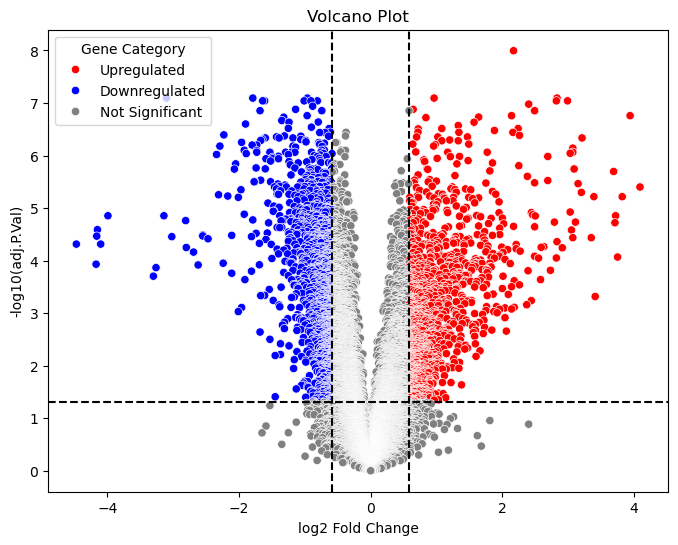

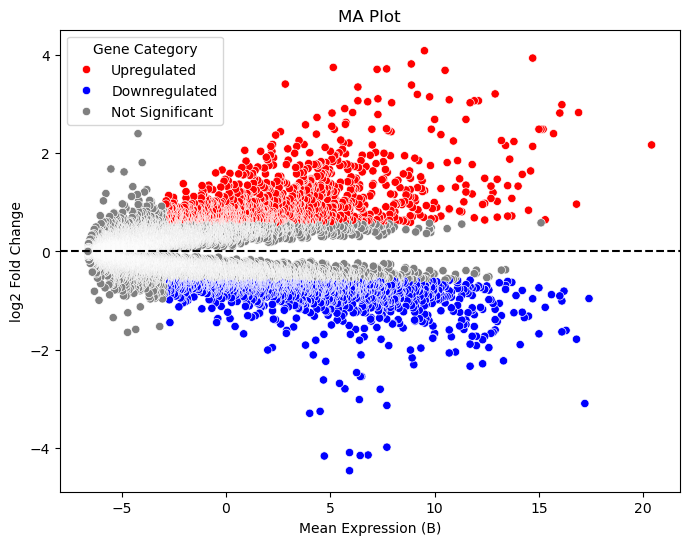

In [4]:
# -----------------------------
# Volcano Plot with 3 colors
# -----------------------------
plt.figure(figsize=(8,6))

# Define categories
conditions = []
for idx, row in deg_data.iterrows():
    if row['adj.P.Val'] < 0.05 and row['logFC'] >= logFC_cut:
        conditions.append('Upregulated')
    elif row['adj.P.Val'] < 0.05 and row['logFC'] <= -logFC_cut:
        conditions.append('Downregulated')
    else:
        conditions.append('Not Significant')

deg_data['Category'] = conditions

# Plot
palette = {'Upregulated':'red', 'Downregulated':'blue', 'Not Significant':'grey'}
sns.scatterplot(x=deg_data['logFC'], y=-np.log10(deg_data['adj.P.Val']),
                hue=deg_data['Category'], palette=palette)
plt.axvline(logFC_cut, linestyle='--', color='black')
plt.axvline(-logFC_cut, linestyle='--', color='black')
plt.axhline(-np.log10(0.05), linestyle='--', color='black')
plt.xlabel('log2 Fold Change')
plt.ylabel('-log10(adj.P.Val)')
plt.title('Volcano Plot')
plt.legend(title='Gene Category')
plt.savefig("Volcano_plot_3colors.png")
plt.show()


# -----------------------------
# MA Plot with 3 colors
# -----------------------------
plt.figure(figsize=(8,6))
mean_expr = deg_data['B']  # or use expression mean if available

sns.scatterplot(x=mean_expr, y=deg_data['logFC'], hue=deg_data['Category'], palette=palette)
plt.axhline(0, linestyle='--', color='black')
plt.xlabel('Mean Expression (B)')
plt.ylabel('log2 Fold Change')
plt.title('MA Plot')
plt.legend(title='Gene Category')
plt.savefig("MA_plot_3colors.png")
plt.show()


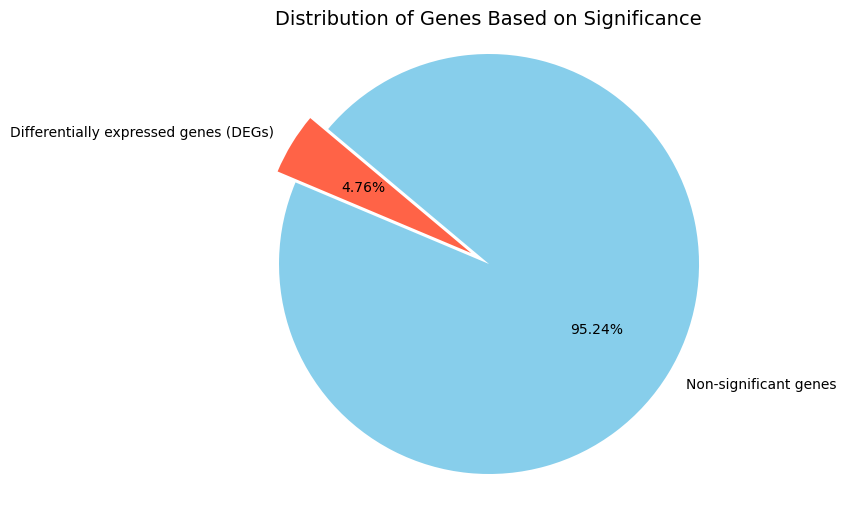

In [16]:
import matplotlib.pyplot as plt

# Data
categories = ['Differentially expressed genes (DEGs)', 'Non-significant genes']
numbers = [2603, 52072]  # Number of genes
colors = ['#FF6347', '#87CEEB']  # Colors for clarity

# Create pie chart
plt.figure(figsize=(8, 6))
plt.pie(numbers, labels=categories, colors=colors, autopct='%1.2f%%', startangle=140, explode=(0.1, 0))
plt.title('Distribution of Genes Based on Significance', fontsize=14)
plt.axis('equal')  # Equal aspect ratio ensures pie is circular

# Show the plot
plt.show()


In [23]:
# Step 0: Install required packages if not already installed
# pip install pandas numpy scipy statsmodels openpyxl matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests
from sklearn.utils import resample
from sklearn.model_selection import KFold

# Step 1: Read your Excel file
file_path = r"C:\Users\Imran Zafar\Downloads\DEG.xlsx"
df = pd.read_excel(file_path)

# Display first rows to check the data
print(df.head())

# Step 2: Basic summary statistics
print(df.describe())

# Assuming your file has columns: "Gene", "logFC" (log fold change), "pval", "padj"
# Adjust column names if different
genes = df['Gene']
logFC = df['logFC']
pval = df['pval']
padj = df['padj']

# Step 3: Effect sizes with 95% confidence intervals
# Here, we approximate 95% CI using standard error from logFC
se_logFC = (logFC.max() - logFC.min()) / (2*1.96)  # rough estimate, adjust if variance column exists
ci_lower = logFC - 1.96*se_logFC
ci_upper = logFC + 1.96*se_logFC
df['CI_lower'] = ci_lower
df['CI_upper'] = ci_upper

# Step 4: Volcano plot (logFC vs -log10(padj))
plt.figure(figsize=(8,6))
sns.scatterplot(x=logFC, y=-np.log10(padj), hue=(padj<0.05), palette={True:'red', False:'grey'})
plt.axhline(-np.log10(0.05), linestyle='--', color='blue')
plt.axvline(1.5, linestyle='--', color='green')
plt.axvline(-1.5, linestyle='--', color='green')
plt.title("Volcano Plot of DEGs")
plt.xlabel("Log2 Fold Change")
plt.ylabel("-log10 Adjusted p-value")
plt.show()

# Step 5: FDR diagnostic plots
# Histogram of q-values (adjusted p-values)
plt.figure(figsize=(6,4))
sns.histplot(padj, bins=50, kde=True, color='skyblue')
plt.title("Distribution of Adjusted p-values (q-values)")
plt.xlabel("Adjusted p-value")
plt.ylabel("Frequency")
plt.show()

# Step 6: Top DEGs stability using bootstrap
n_bootstrap = 1000
top_genes_list = []
for i in range(n_bootstrap):
    sample_df = resample(df, replace=True, n_samples=len(df))
    top_genes = sample_df.nsmallest(50, 'padj')['Gene'].tolist()
    top_genes_list.extend(top_genes)

# Count frequency of top genes
top_gene_counts = pd.Series(top_genes_list).value_counts()
print("Top 10 most stable genes across bootstrap samples:")
print(top_gene_counts.head(10))

# Step 7: Optional k-fold cross-validation stability
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_top_genes = []

for train_index, test_index in kf.split(df):
    train_df = df.iloc[train_index]
    top_genes_fold = train_df.nsmallest(50, 'padj')['Gene'].tolist()
    fold_top_genes.extend(top_genes_fold)

fold_top_counts = pd.Series(fold_top_genes).value_counts()
print("Top 10 most stable genes across k-fold CV:")
print(fold_top_counts.head(10))

# Step 8: Save annotated DEG table with CI
df.to_excel(r"C:\Users\Imran Zafar\Downloads\DEG_with_CI.xlsx", index=False)
print("Annotated DEG table with 95% CI saved successfully.")


            ID     adj.P.Val       P.Value     t     B  logFC     Gene.symbol  \
0    225239_at  1.010000e-08  1.840000e-13  13.0  20.4  2.170  MIR612///NEAT1   
1  200946_x_at  8.050000e-08  4.730000e-12 -11.3  17.4 -0.961           GLUD1   
2    228697_at  8.050000e-08  5.440000e-12 -11.3  17.2 -3.100           HINT3   
3    205624_at  8.050000e-08  8.050000e-12  11.1  16.9  2.830            CPA3   
4    243869_at  8.050000e-08  8.610000e-12  11.0  16.8  0.963             NaN   

                                          Gene.title  
0  microRNA 612///nuclear paraspeckle assembly tr...  
1                          glutamate dehydrogenase 1  
2       histidine triad nucleotide binding protein 3  
3                                carboxypeptidase A3  
4                                                NaN  
          adj.P.Val       P.Value             t             B         logFC
count  5.467500e+04  5.467500e+04  54675.000000  54675.000000  54675.000000
mean   4.363405e-01  3.090035e-

KeyError: 'Gene'

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.power import TTestIndPower
from sklearn.utils import resample
from sklearn.model_selection import KFold

file_path = r"C:\Users\Imran Zafar\Downloads\DEG.xlsx"
df = pd.read_excel(file_path)

gene_col = 'Gene.title'
logFC_col = 'logFC'
pval_col = 'P.Value'
padj_col = 'adj.P.Val'


In [29]:
# Empirical variance from observed logFC
variance = np.var(df[logFC_col], ddof=1)
std_dev = np.sqrt(variance)

# Effect size (Cohen's d approximation)
effect_size = df[logFC_col].mean() / std_dev

power_analysis = TTestIndPower()
power = power_analysis.solve_power(
    effect_size=effect_size,
    nobs1=len(df),
    alpha=0.05
)

print("Empirical variance:", variance)
print("Effect size (Cohen's d):", effect_size)
print("Post-hoc statistical power:", power)


Empirical variance: 0.08707149061361721
Effect size (Cohen's d): -0.008122070399275818
Post-hoc statistical power: 0.2690734152262429


In [31]:
se = df[logFC_col].std(ddof=1) / np.sqrt(len(df))
df['CI_lower'] = df[logFC_col] - 1.96 * se
df['CI_upper'] = df[logFC_col] + 1.96 * se


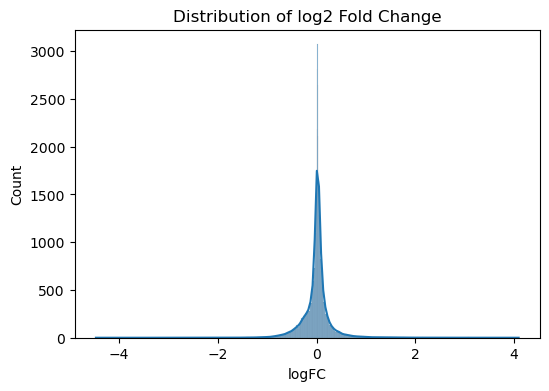

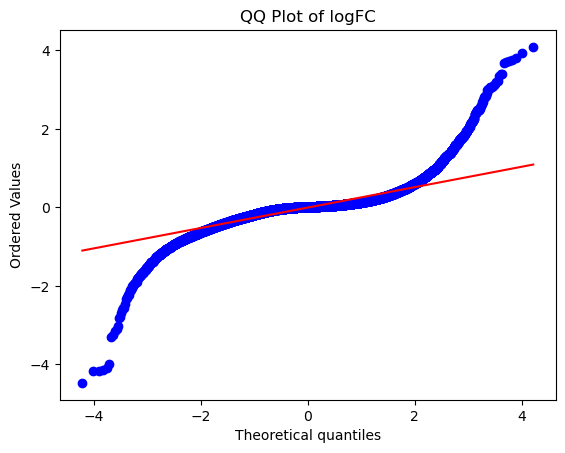

In [32]:
plt.figure(figsize=(6,4))
sns.histplot(df[logFC_col], kde=True)
plt.title("Distribution of log2 Fold Change")
plt.show()

stats.probplot(df[logFC_col], plot=plt)
plt.title("QQ Plot of logFC")
plt.show()


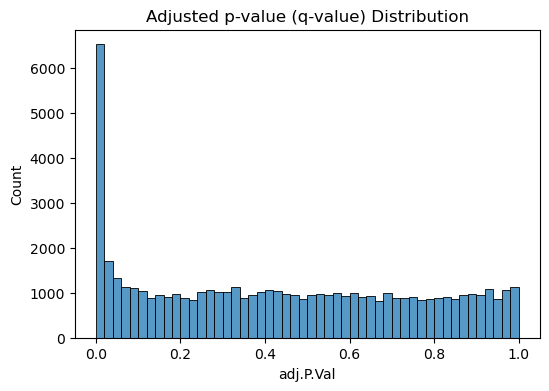

Estimated π₀ (true null proportion): 0.4291175125743027


In [33]:
plt.figure(figsize=(6,4))
sns.histplot(df[padj_col], bins=50)
plt.title("Adjusted p-value (q-value) Distribution")
plt.show()

pi0 = np.mean(df[padj_col] > 0.5)
print("Estimated π₀ (true null proportion):", pi0)


In [34]:
top_n = 50
bootstrap_genes = []

for i in range(1000):
    sample = resample(df, replace=True)
    top = sample.nsmallest(top_n, padj_col)[gene_col]
    bootstrap_genes.extend(top)

bootstrap_counts = pd.Series(bootstrap_genes).value_counts()
print("Top stable genes (bootstrap):")
print(bootstrap_counts.head(10))


Top stable genes (bootstrap):
hemoglobin subunit alpha 2///hemoglobin subunit alpha 1                          4919
microRNA 612///nuclear paraspeckle assembly transcript 1 (non-protein coding)    3032
hemoglobin subunit beta                                                          3011
histidine triad nucleotide binding protein 3                                     2009
glutamate dehydrogenase 1                                                        1947
oxysterol binding protein                                                        1122
proteasome subunit beta 4                                                        1060
signal transducer and activator of transcription 2                               1050
carboxypeptidase A3                                                              1041
membrane spanning 4-domains A3                                                   1039
Name: count, dtype: int64


In [35]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_genes = []

for train_idx, _ in kf.split(df):
    train = df.iloc[train_idx]
    top = train.nsmallest(top_n, padj_col)[gene_col]
    cv_genes.extend(top)

cv_counts = pd.Series(cv_genes).value_counts()
print("Top stable genes (CV):")
print(cv_counts.head(10))


Top stable genes (CV):
hemoglobin subunit alpha 2///hemoglobin subunit alpha 1                          24
microRNA 612///nuclear paraspeckle assembly transcript 1 (non-protein coding)    12
hemoglobin subunit beta                                                          12
histidine triad nucleotide binding protein 3                                      8
glutamate dehydrogenase 1                                                         8
F-box protein 16///zinc finger protein 395                                        5
transmembrane protein 192                                                         4
ASMTL antisense RNA 1                                                             4
proteasome 26S subunit, non-ATPase 5                                              4
apoptotic peptidase activating factor 1                                           4
Name: count, dtype: int64


In [36]:
thresholds = [1.0, 1.5, 2.0]

for t in thresholds:
    count = df[(df[padj_col] < 0.05) & (abs(df[logFC_col]) >= t)].shape[0]
    print(f"logFC ≥ {t}: {count} DEGs")


logFC ≥ 1.0: 709 DEGs
logFC ≥ 1.5: 248 DEGs
logFC ≥ 2.0: 106 DEGs


In [37]:
df.to_excel(r"C:\Users\Imran Zafar\Downloads\DEG_Reviewer_Validated.xlsx", index=False)


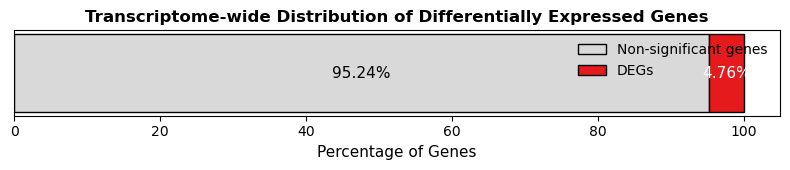

In [39]:
import matplotlib.pyplot as plt

# Data
deg_percent = 4.76
non_deg_percent = 95.24

plt.figure(figsize=(8, 1.8))

# Horizontal stacked bar
plt.barh(
    y=0,
    width=non_deg_percent,
    color='#d9d9d9',
    edgecolor='black',
    label='Non-significant genes'
)
plt.barh(
    y=0,
    width=deg_percent,
    left=non_deg_percent,
    color='#e41a1c',
    edgecolor='black',
    label='DEGs'
)

# Annotations
plt.text(non_deg_percent / 2, 0, '95.24%', va='center', ha='center', fontsize=11)
plt.text(non_deg_percent + deg_percent / 2, 0, '4.76%', va='center', ha='center', fontsize=11, color='white')

plt.yticks([])
plt.xlabel('Percentage of Genes', fontsize=11)
plt.title(
    'Transcriptome-wide Distribution of Differentially Expressed Genes',
    fontsize=12,
    weight='bold'
)

plt.legend(loc='upper right', frameon=False)
plt.tight_layout()
plt.show()
